# Task IX.A — Strategy Discussion

**Approach:** Pretrain a Masked Autoencoder (MAE) on no_sub images to learn general lensing representations, then fine-tune for 3-class substructure classification. MAE is well-suited here because the discriminative signal between classes lies in subtle spatial features (ring sharpness, subhalo clumps) that a pixel-reconstruction objective directly captures.

**Preprocessing — informed by data analysis:** Pixel values span 8 orders of magnitude (1e-10 to ~4.58) with extreme right skew (median is 2,800x smaller than mean). We apply `log1p` followed by per-image z-score normalization to compress dynamic range and spread the near-zero structure where the physics resides. Raw or min-max normalization would waste capacity on rare bright pixels.

**Architecture:** ViT-Small encoder (dim=384, 12 layers, 6 heads) with 8×8 patches producing 64 tokens per 64×64 image. Patch size is chosen because the Einstein ring peaks at radius ~8px — finer patches preserve this structure. The decoder is lightweight (dim=192, 4 layers) since it's discarded after pretraining. Masking ratio is 75%, justified by the steep power spectrum (smooth, low-frequency images tolerate aggressive masking). Model scale follows benchmarks from Lens-JEPA work, which achieved AUC 0.96–1.00 with ViT at comparable dataset sizes.

**Training:** Pretrain with AdamW (lr=1.5e-4, cosine schedule, 20-epoch warmup) on 29,449 no_sub images with physics-motivated augmentations (90° rotations, flips — safe due to confirmed radial symmetry). Fine-tune with differential LR: encoder at 1e-5 (matching this group's published practice), fresh classification head at 1e-4. Label smoothing (0.1) for regularization.

**Evaluation:** Per-class ROC curves and AUC scores (one-vs-rest), targeting the group's benchmark of AUC ≥ 0.96 across classes.

## Imports and Config

In [1]:
#Imports and Config
import os
import glob
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from functools import partial
from pathlib import Path
import time
import warnings
warnings.filterwarnings('ignore')
 
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
 
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
 
# ─── CONFIGURATION ───────────────────────────────────────────────────
class Config:
    # Paths
    alpha_root = "alpha/Dataset"   # axion/, cdm/, no_sub/ inside
 
    # Data
    img_size = 64
    in_channels = 1
 
    # ViT-Small Encoder
    patch_size = 8
    num_patches = (img_size // 8) ** 2  # 64
    encoder_dim = 384
    encoder_depth = 12
    encoder_heads = 6
 
    # MAE Decoder (lightweight)
    decoder_dim = 192
    decoder_depth = 4
    decoder_heads = 4
    mask_ratio = 0.75
 
    # Pretraining
    pretrain_epochs = 200
    pretrain_batch_size = 256
    pretrain_lr = 1.5e-4
    pretrain_weight_decay = 0.05
    warmup_epochs = 20
 
    # Fine-tuning
    finetune_epochs = 50
    finetune_batch_size = 128
    finetune_lr = 1e-4
    finetune_weight_decay = 0.05
    ft_warmup_epochs = 5
    num_classes = 3
    label_smoothing = 0.1
 
    # General
    num_workers = 4
    drop_path_rate = 0.1
 
cfg = Config()
print(f"Patches: {cfg.num_patches} ({cfg.img_size}÷{cfg.patch_size})²")
print(f"Visible tokens per image: {int(cfg.num_patches * (1 - cfg.mask_ratio))}")

Device: cuda
GPU: NVIDIA H200 NVL
Memory: 150.1 GB
Patches: 64 (64÷8)²
Visible tokens per image: 16


## Dataset

In [2]:
# Dataset
class LensingDataset(Dataset):
    """
    Loads .npy lensing images with log1p + per-image z-score normalization.
    Handles axion's pickled tuple format (a[0]=image, a[1]=scalar).
    """
    def __init__(self, file_paths, labels=None, augment=False):
        self.file_paths = file_paths
        self.labels = labels
        self.augment = augment
 
    def __len__(self):
        return len(self.file_paths)
 
    def _load_image(self, path):
        a = np.load(path, allow_pickle=True)
        if a.dtype == object:
            img = a[0].astype(np.float32)  # axion: extract from tuple
        else:
            img = a.astype(np.float32)
        return img  # (64, 64)
 
    def __getitem__(self, idx):
        img = self._load_image(self.file_paths[idx])
 
        # log1p normalization (compress 8-order dynamic range)
        img = np.log1p(img)
 
        # Per-image z-score
        mu = img.mean()
        std = img.std()
        img = (img - mu) / (std + 1e-8)
 
        # To tensor (1, 64, 64)
        img = torch.from_numpy(img).unsqueeze(0)
 
        # Augmentations (physics-justified: lensing images are rotationally symmetric)
        if self.augment:
            # Random 90° rotations
            k = random.randint(0, 3)
            if k > 0:
                img = torch.rot90(img, k, dims=[1, 2])
            # Random horizontal flip
            if random.random() > 0.5:
                img = torch.flip(img, dims=[2])
            # Random vertical flip
            if random.random() > 0.5:
                img = torch.flip(img, dims=[1])
 
        if self.labels is not None:
            return img, self.labels[idx]
        return img
 
# Load file paths
def get_file_paths(root, class_name):
    d = os.path.join(root, class_name)
    return sorted(glob.glob(os.path.join(d, "*.npy")))
 
# Pretraining: no_sub only
pretrain_files = get_file_paths(cfg.alpha_root, "no_sub")
print(f"Pretraining files (no_sub): {len(pretrain_files)}")
 
# Classification: all classes
class_names = ["no_sub", "cdm", "axion"]
all_files = []
all_labels = []
for i, cls in enumerate(class_names):
    files = get_file_paths(cfg.alpha_root, cls)
    all_files.extend(files)
    all_labels.extend([i] * len(files))
    print(f"  {cls}: {len(files)}")
 
all_labels = np.array(all_labels)
print(f"Total classification files: {len(all_files)}")
 
# Train/test split (90/10, stratified) — per submission guidelines
train_idx, test_idx = train_test_split(
    range(len(all_files)), test_size=0.1, stratify=all_labels, random_state=SEED)

print(f"\nClassification split: train={len(train_idx)}, test={len(test_idx)}")

Pretraining files (no_sub): 29449
  no_sub: 29449
  cdm: 29759
  axion: 29896
Total classification files: 89104

Classification split: train=80193, test=8911


## MAE Architecture

In [3]:
# ── Patch Embedding ──────────────────────────────────────────────────
class PatchEmbed(nn.Module):
    def __init__(self, img_size=64, patch_size=8, in_channels=1, embed_dim=384):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
 
    def forward(self, x):
        # x: (B, 1, 64, 64) → (B, num_patches, embed_dim)
        return self.proj(x).flatten(2).transpose(1, 2)
 
# ── Transformer Block with Drop Path ────────────────────────────────
class DropPath(nn.Module):
    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob
 
    def forward(self, x):
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        mask = torch.bernoulli(torch.full(shape, keep, device=x.device)) / keep
        return x * mask
 
class Attention(nn.Module):
    def __init__(self, dim, num_heads=6, qkv_bias=True, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)
 
    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj_drop(self.proj(x))
 
class MLP(nn.Module):
    def __init__(self, dim, hidden_dim, drop=0.):
        super().__init__()
        self.fc1 = nn.Linear(dim, hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, dim)
        self.drop = nn.Dropout(drop)
 
    def forward(self, x):
        return self.drop(self.fc2(self.drop(self.act(self.fc1(x)))))
 
class TransformerBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4., drop_path=0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads)
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = MLP(dim, int(dim * mlp_ratio))
 
    def forward(self, x):
        x = x + self.drop_path(self.attn(self.norm1(x)))
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x
 
# ── MAE Encoder ──────────────────────────────────────────────────────
class MAEEncoder(nn.Module):
    def __init__(self, img_size=64, patch_size=8, in_channels=1,
                 embed_dim=384, depth=12, num_heads=6, drop_path_rate=0.1):
        super().__init__()
        self.patch_embed = PatchEmbed(img_size, patch_size, in_channels, embed_dim)
        self.num_patches = self.patch_embed.num_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + self.num_patches, embed_dim))
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, depth)]
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, drop_path=dpr[i])
            for i in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.embed_dim = embed_dim
        self._init_weights()
 
    def _init_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.apply(self._init_module)
 
    def _init_module(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)
 
    def random_masking(self, x, mask_ratio):
        B, N, D = x.shape
        len_keep = int(N * (1 - mask_ratio))
 
        noise = torch.rand(B, N, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)
 
        ids_keep = ids_shuffle[:, :len_keep]
        x_masked = torch.gather(x, 1, ids_keep.unsqueeze(-1).expand(-1, -1, D))
 
        mask = torch.ones(B, N, device=x.device)
        mask[:, :len_keep] = 0
        mask = torch.gather(mask, 1, ids_restore)
 
        return x_masked, mask, ids_restore
 
    def forward_encoder(self, x, mask_ratio):
        """Encode with masking for MAE pretraining."""
        x = self.patch_embed(x)  # (B, N, D)
        x = x + self.pos_embed[:, 1:, :]  # add positional embed (no cls)
 
        x, mask, ids_restore = self.random_masking(x, mask_ratio)
 
        # Prepend cls token
        cls_tokens = self.cls_token + self.pos_embed[:, :1, :]
        cls_tokens = cls_tokens.expand(x.shape[0], -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
 
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
 
        return x, mask, ids_restore
 
    def forward(self, x):
        """Full forward without masking (for fine-tuning)."""
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)
        x = x + self.pos_embed
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
        return x
 
# ── MAE Decoder ──────────────────────────────────────────────────────
class MAEDecoder(nn.Module):
    def __init__(self, num_patches=64, patch_size=8, in_channels=1,
                 encoder_dim=384, decoder_dim=192, depth=4, num_heads=4):
        super().__init__()
        self.decoder_embed = nn.Linear(encoder_dim, decoder_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_dim))
        self.decoder_pos_embed = nn.Parameter(torch.zeros(1, 1 + num_patches, decoder_dim))
        self.blocks = nn.ModuleList([
            TransformerBlock(decoder_dim, num_heads) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(decoder_dim)
        self.pred = nn.Linear(decoder_dim, patch_size ** 2 * in_channels)
        self.num_patches = num_patches
        self._init_weights()
 
    def _init_weights(self):
        nn.init.trunc_normal_(self.decoder_pos_embed, std=0.02)
        nn.init.trunc_normal_(self.mask_token, std=0.02)
 
    def forward(self, x, ids_restore):
        x = self.decoder_embed(x)
 
        # Append mask tokens
        mask_tokens = self.mask_token.repeat(x.shape[0], ids_restore.shape[1] + 1 - x.shape[1], 1)
        x_ = torch.cat([x[:, 1:, :], mask_tokens], dim=1)  # skip cls
        x_ = torch.gather(x_, 1, ids_restore.unsqueeze(-1).expand(-1, -1, x_.shape[2]))
        x = torch.cat([x[:, :1, :], x_], dim=1)  # add cls back
 
        x = x + self.decoder_pos_embed
 
        for blk in self.blocks:
            x = blk(x)
        x = self.norm(x)
 
        # Predict pixel values (skip cls)
        x = self.pred(x[:, 1:, :])
        return x
 
# ── Full MAE Model ───────────────────────────────────────────────────
class MAE(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.encoder = MAEEncoder(
            img_size=cfg.img_size, patch_size=cfg.patch_size,
            in_channels=cfg.in_channels, embed_dim=cfg.encoder_dim,
            depth=cfg.encoder_depth, num_heads=cfg.encoder_heads,
            drop_path_rate=cfg.drop_path_rate,
        )
        self.decoder = MAEDecoder(
            num_patches=cfg.num_patches, patch_size=cfg.patch_size,
            in_channels=cfg.in_channels, encoder_dim=cfg.encoder_dim,
            decoder_dim=cfg.decoder_dim, depth=cfg.decoder_depth,
            num_heads=cfg.decoder_heads,
        )
        self.patch_size = cfg.patch_size
        self.mask_ratio = cfg.mask_ratio
 
    def patchify(self, imgs):
        """(B, 1, H, W) → (B, N, patch_size²)"""
        p = self.patch_size
        B, C, H, W = imgs.shape
        h, w = H // p, W // p
        x = imgs.reshape(B, C, h, p, w, p)
        x = x.permute(0, 2, 4, 3, 5, 1).reshape(B, h * w, p * p * C)
        return x
 
    def unpatchify(self, x):
        """(B, N, patch_size²) → (B, 1, H, W)"""
        p = self.patch_size
        h = w = int(x.shape[1] ** 0.5)
        C = 1
        x = x.reshape(-1, h, w, p, p, C)
        x = x.permute(0, 5, 1, 3, 2, 4).reshape(-1, C, h * p, w * p)
        return x
 
    def forward(self, imgs):
        latent, mask, ids_restore = self.encoder.forward_encoder(imgs, self.mask_ratio)
        pred = self.decoder(latent, ids_restore)
        target = self.patchify(imgs)
 
        # MSE loss on masked patches only
        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)  # per-patch MSE
        loss = (loss * mask).sum() / mask.sum()  # only masked patches
 
        return loss, pred, mask
 
model = MAE(cfg).to(device)
n_params = sum(p.numel() for p in model.parameters()) / 1e6
n_enc = sum(p.numel() for p in model.encoder.parameters()) / 1e6
n_dec = sum(p.numel() for p in model.decoder.parameters()) / 1e6
print(f"MAE total: {n_params:.1f}M params (encoder: {n_enc:.1f}M, decoder: {n_dec:.1f}M)")

MAE total: 23.2M params (encoder: 21.3M, decoder: 1.9M)


## MAE Pretraining

Pretraining: 29449 images, 115 batches/epoch
Epochs: 200, Warmup: 20
Epoch   1/200 | Loss: 1.2708 | Best: 1.2708 | LR: 0.00e+00 | Time: 17s
Epoch  20/200 | Loss: 0.0175 | Best: 0.0175 | LR: 1.42e-04 | Time: 115s
Epoch  40/200 | Loss: 0.0047 | Best: 0.0047 | LR: 1.46e-04 | Time: 221s
Epoch  60/200 | Loss: 0.0026 | Best: 0.0026 | LR: 1.33e-04 | Time: 317s
Epoch  80/200 | Loss: 0.0018 | Best: 0.0018 | LR: 1.14e-04 | Time: 415s
Epoch 100/200 | Loss: 0.0012 | Best: 0.0012 | LR: 8.97e-05 | Time: 510s
Epoch 120/200 | Loss: 0.0007 | Best: 0.0007 | LR: 6.38e-05 | Time: 607s
Epoch 140/200 | Loss: 0.0005 | Best: 0.0005 | LR: 3.94e-05 | Time: 703s
Epoch 160/200 | Loss: 0.0003 | Best: 0.0003 | LR: 1.93e-05 | Time: 799s
Epoch 180/200 | Loss: 0.0002 | Best: 0.0002 | LR: 5.95e-06 | Time: 895s
Epoch 200/200 | Loss: 0.0001 | Best: 0.0001 | LR: 1.01e-06 | Time: 991s

Pretraining complete in 991s (16.5 min)
Best reconstruction loss: 0.0001


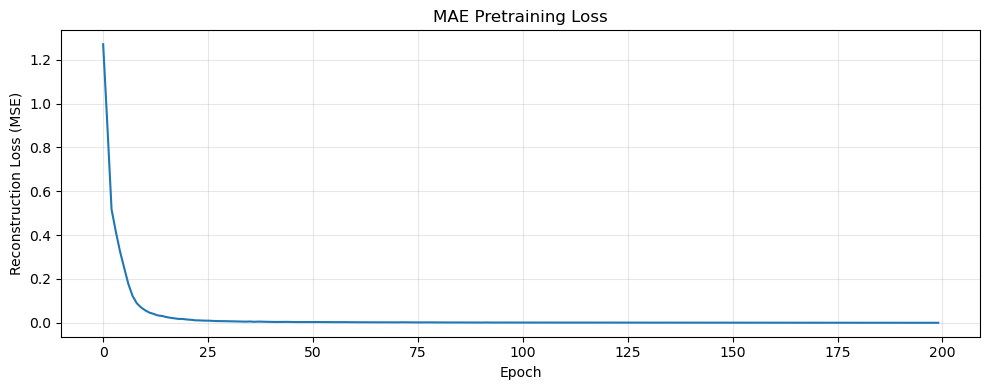

In [4]:
# Cosine schedule with warmup
def get_lr(epoch, total_epochs, warmup_epochs, base_lr, min_lr=1e-6):
    if epoch < warmup_epochs:
        return base_lr * epoch / warmup_epochs
    progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
    return min_lr + 0.5 * (base_lr - min_lr) * (1 + math.cos(math.pi * progress))
 
# Pretraining dataset & loader
pretrain_dataset = LensingDataset(pretrain_files, labels=None, augment=True)
pretrain_loader = DataLoader(
    pretrain_dataset, batch_size=cfg.pretrain_batch_size, shuffle=True,
    num_workers=cfg.num_workers, pin_memory=True, drop_last=True,
)
 
print(f"Pretraining: {len(pretrain_dataset)} images, {len(pretrain_loader)} batches/epoch")
print(f"Epochs: {cfg.pretrain_epochs}, Warmup: {cfg.warmup_epochs}")
 
# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(), lr=cfg.pretrain_lr,
    betas=(0.9, 0.95), weight_decay=cfg.pretrain_weight_decay,
)
 
# Training loop
pretrain_losses = []
best_loss = float('inf')
t_start = time.time()
 
for epoch in range(cfg.pretrain_epochs):
    model.train()
    epoch_loss = 0.0
    n_batches = 0
 
    # Update LR
    lr = get_lr(epoch, cfg.pretrain_epochs, cfg.warmup_epochs, cfg.pretrain_lr)
    for pg in optimizer.param_groups:
        pg['lr'] = lr
 
    for batch in pretrain_loader:
        imgs = batch.to(device)
        loss, _, _ = model(imgs)
 
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
 
        epoch_loss += loss.item()
        n_batches += 1
 
    avg_loss = epoch_loss / n_batches
    pretrain_losses.append(avg_loss)
 
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.encoder.state_dict(), "mae_encoder_best.pth")
 
    if (epoch + 1) % 20 == 0 or epoch == 0:
        elapsed = time.time() - t_start
        print(f"Epoch {epoch+1:>3d}/{cfg.pretrain_epochs} | "
              f"Loss: {avg_loss:.4f} | Best: {best_loss:.4f} | "
              f"LR: {lr:.2e} | Time: {elapsed:.0f}s")
 
total_time = time.time() - t_start
print(f"\nPretraining complete in {total_time:.0f}s ({total_time/60:.1f} min)")
print(f"Best reconstruction loss: {best_loss:.4f}")
 
# Save final
torch.save(model.encoder.state_dict(), "mae_encoder_final.pth")
torch.save(model.state_dict(), "mae_full_final.pth")
 
# Plot loss curve
plt.figure(figsize=(10, 4))
plt.plot(pretrain_losses)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss (MSE)")
plt.title("MAE Pretraining Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("pretrain_loss.png", dpi=150)
plt.show()

## MAE Visualization

In [5]:
model.load_state_dict(torch.load("mae_full_final.pth", map_location=device))
print("Loaded pretrained MAE weights.")

Loaded pretrained MAE weights.


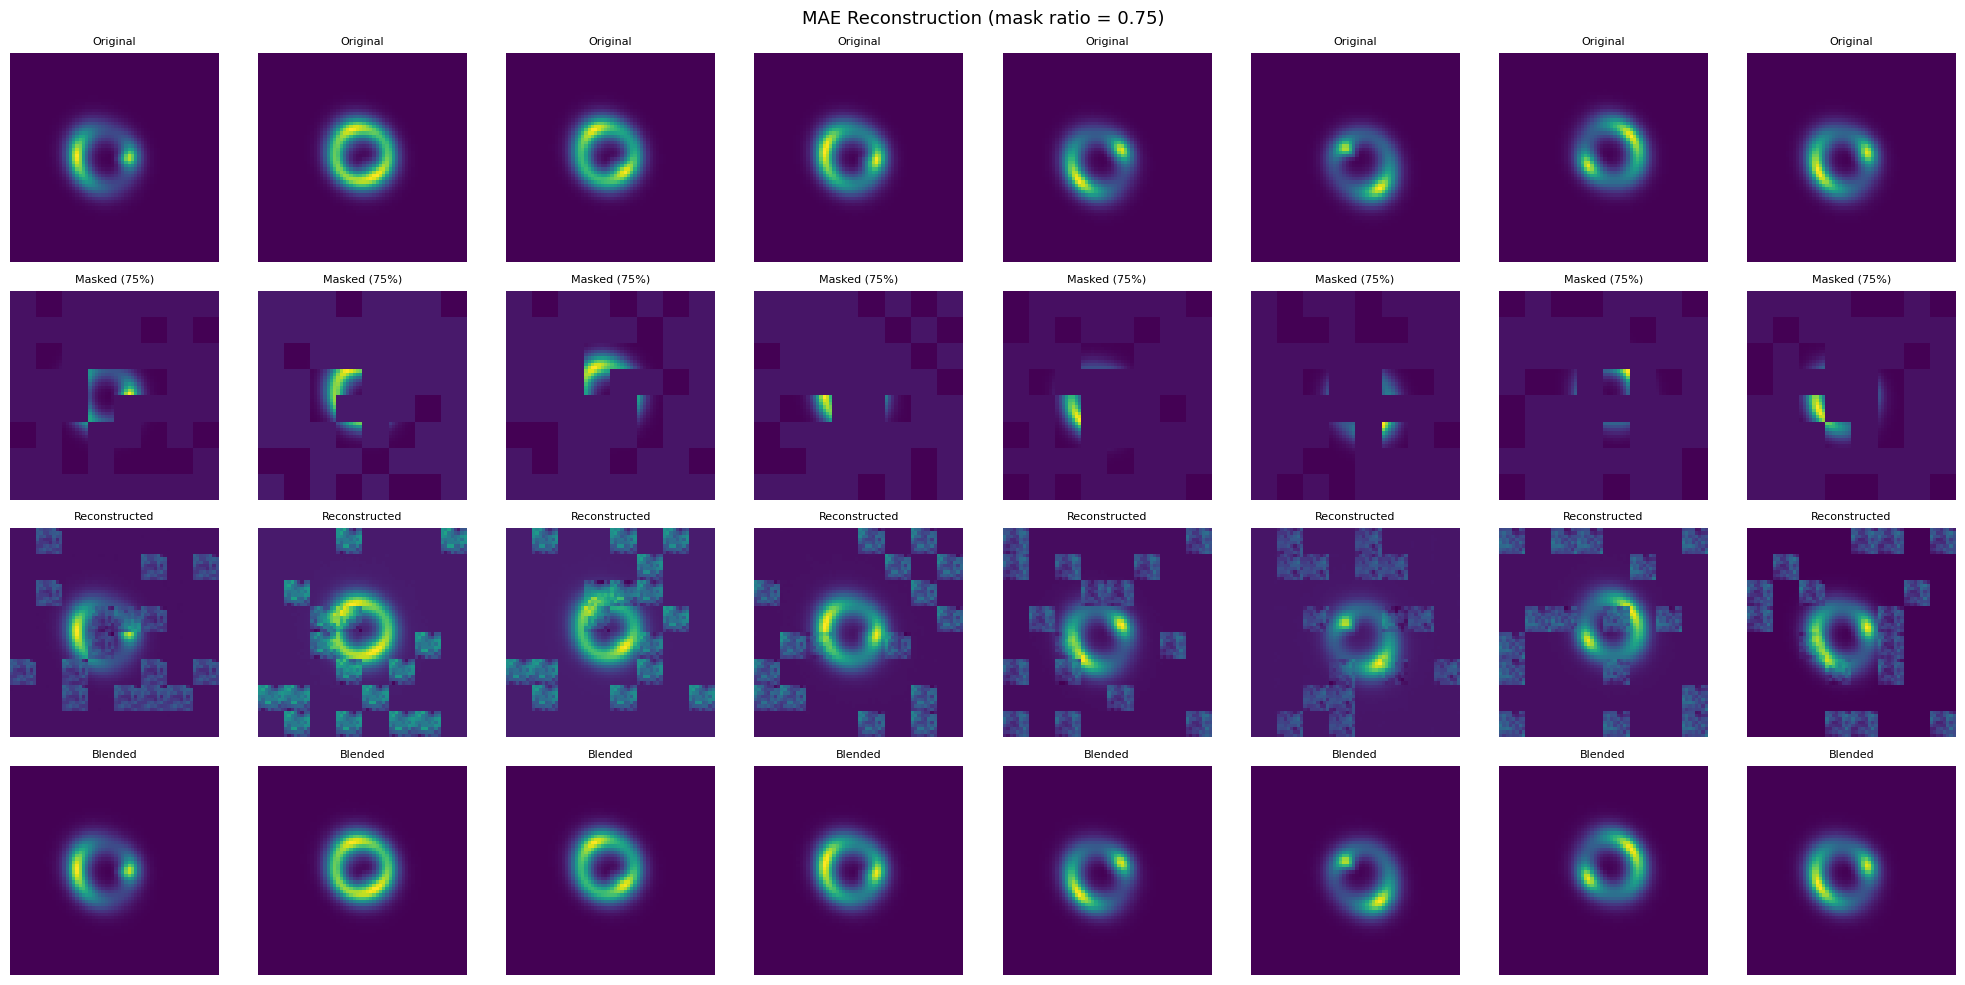

In [6]:
model.eval()
vis_dataset = LensingDataset(pretrain_files[:8], labels=None, augment=False)
vis_loader = DataLoader(vis_dataset, batch_size=8, shuffle=False)
imgs = next(iter(vis_loader)).to(device)
 
with torch.no_grad():
    loss, pred, mask = model(imgs)
 
# Reconstruct
pred_imgs = model.unpatchify(pred)
mask_imgs = mask.unsqueeze(-1).repeat(1, 1, cfg.patch_size**2)
mask_imgs = model.unpatchify(mask_imgs)
 
fig, axes = plt.subplots(4, 8, figsize=(20, 10))
for i in range(min(8, imgs.shape[0])):
    # Original
    axes[0, i].imshow(imgs[i, 0].cpu(), cmap='viridis')
    axes[0, i].set_title("Original", fontsize=8)
    axes[0, i].axis('off')
 
    # Masked
    masked = imgs[i, 0].cpu() * (1 - mask_imgs[i, 0].cpu())
    axes[1, i].imshow(masked, cmap='viridis')
    axes[1, i].set_title("Masked (75%)", fontsize=8)
    axes[1, i].axis('off')
 
    # Reconstruction
    axes[2, i].imshow(pred_imgs[i, 0].cpu(), cmap='viridis')
    axes[2, i].set_title("Reconstructed", fontsize=8)
    axes[2, i].axis('off')
 
    # Blended (visible + reconstructed masked)
    blended = imgs[i, 0].cpu() * (1 - mask_imgs[i, 0].cpu()) + pred_imgs[i, 0].cpu() * mask_imgs[i, 0].cpu()
    axes[3, i].imshow(blended, cmap='viridis')
    axes[3, i].set_title("Blended", fontsize=8)
    axes[3, i].axis('off')
 
axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("Masked", fontsize=10)
axes[2, 0].set_ylabel("Predicted", fontsize=10)
axes[3, 0].set_ylabel("Blended", fontsize=10)
 
plt.suptitle(f"MAE Reconstruction (mask ratio = {cfg.mask_ratio})", fontsize=13)
plt.tight_layout()
plt.savefig("mae_reconstructions.png", dpi=150)
plt.show()

## Classification & Finetuning

In [4]:
def get_lr(epoch, total_epochs, warmup_epochs, base_lr, min_lr=1e-6):
    if epoch < warmup_epochs:
        return base_lr * epoch / warmup_epochs
    progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
    return min_lr + 0.5 * (base_lr - min_lr) * (1 + math.cos(math.pi * progress))

Loaded pretrained encoder weights.
Train: 80193, Test: 8911
Epoch  1/50 | Loss: 1.3548 | Acc: 0.3327 | LR: 0.00e+00 | 26s
Epoch  2/50 | Loss: 0.9425 | Acc: 0.5874 | LR: 2.00e-05 | 52s
Epoch  3/50 | Loss: 0.5590 | Acc: 0.8569 | LR: 4.00e-05 | 77s
Epoch  4/50 | Loss: 0.4932 | Acc: 0.8872 | LR: 6.00e-05 | 103s
Epoch  5/50 | Loss: 0.4709 | Acc: 0.8990 | LR: 8.00e-05 | 129s
Epoch  6/50 | Loss: 0.4651 | Acc: 0.9007 | LR: 1.00e-04 | 154s
Epoch  7/50 | Loss: 0.4467 | Acc: 0.9107 | LR: 9.99e-05 | 180s
Epoch  8/50 | Loss: 0.4457 | Acc: 0.9111 | LR: 9.95e-05 | 205s
Epoch  9/50 | Loss: 0.4374 | Acc: 0.9159 | LR: 9.89e-05 | 231s
Epoch 10/50 | Loss: 0.4200 | Acc: 0.9259 | LR: 9.81e-05 | 256s
Epoch 11/50 | Loss: 0.4144 | Acc: 0.9301 | LR: 9.70e-05 | 282s
Epoch 12/50 | Loss: 0.4124 | Acc: 0.9310 | LR: 9.57e-05 | 307s
Epoch 13/50 | Loss: 0.4134 | Acc: 0.9313 | LR: 9.42e-05 | 333s
Epoch 14/50 | Loss: 0.4019 | Acc: 0.9374 | LR: 9.25e-05 | 358s
Epoch 15/50 | Loss: 0.3961 | Acc: 0.9406 | LR: 9.05e-05 | 384

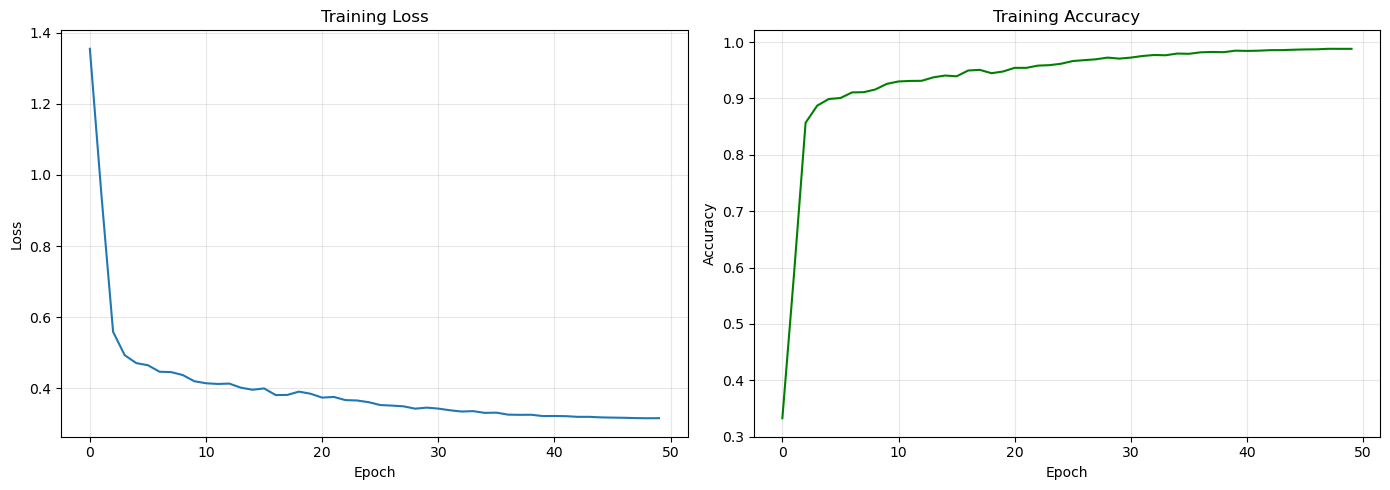

In [5]:


class ClassificationHead(nn.Module):
    """Pretrained MAE encoder + classification head."""
    def __init__(self, encoder, embed_dim=384, num_classes=3):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(0.1),
            nn.Linear(embed_dim, num_classes),
        )

    def forward(self, x):
        x = self.encoder(x)
        cls_token = x[:, 0]
        return self.head(cls_token)

# Load best pretrained encoder
encoder = MAEEncoder(
    img_size=cfg.img_size, patch_size=cfg.patch_size,
    in_channels=cfg.in_channels, embed_dim=cfg.encoder_dim,
    depth=cfg.encoder_depth, num_heads=cfg.encoder_heads,
    drop_path_rate=cfg.drop_path_rate,
).to(device)
encoder.load_state_dict(torch.load("mae_encoder_best.pth", map_location=device))
print("Loaded pretrained encoder weights.")

classifier = ClassificationHead(encoder, cfg.encoder_dim, cfg.num_classes).to(device)

# Datasets (90/10 split)
train_files = [all_files[i] for i in train_idx]
train_labels_split = all_labels[train_idx]
test_files = [all_files[i] for i in test_idx]
test_labels_split = all_labels[test_idx]

train_dataset = LensingDataset(train_files, train_labels_split, augment=True)
test_dataset = LensingDataset(test_files, test_labels_split, augment=False)

train_loader = DataLoader(train_dataset, batch_size=cfg.finetune_batch_size,
                          shuffle=True, num_workers=cfg.num_workers, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=cfg.finetune_batch_size,
                         shuffle=False, num_workers=cfg.num_workers, pin_memory=True)

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")

# Optimizer — lower LR for pretrained encoder, higher for fresh head
optimizer_ft = torch.optim.AdamW([
    {"params": classifier.encoder.parameters(), "lr": cfg.finetune_lr * 0.1},
    {"params": classifier.head.parameters(), "lr": cfg.finetune_lr},
], betas=(0.9, 0.999), weight_decay=cfg.finetune_weight_decay)

criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)

# Fine-tuning loop
train_losses, train_accs = [], []
t_start = time.time()

for epoch in range(cfg.finetune_epochs):
    classifier.train()
    epoch_loss = 0.0
    correct = 0
    total = 0

    # LR schedule
    lr = get_lr(epoch, cfg.finetune_epochs, cfg.ft_warmup_epochs, cfg.finetune_lr, min_lr=1e-6)
    optimizer_ft.param_groups[0]['lr'] = lr * 0.1  # encoder: 1e-5
    optimizer_ft.param_groups[1]['lr'] = lr          # head: 1e-4

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = classifier(imgs)
        loss = criterion(logits, labels)

        optimizer_ft.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(classifier.parameters(), 1.0)
        optimizer_ft.step()

        epoch_loss += loss.item() * imgs.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += imgs.size(0)

    train_loss = epoch_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    elapsed = time.time() - t_start
    print(f"Epoch {epoch+1:>2d}/{cfg.finetune_epochs} | "
          f"Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | "
          f"LR: {lr:.2e} | {elapsed:.0f}s")

# Save final model
torch.save(classifier.state_dict(), "classifier_bestkg.pth")

print(f"\nFine-tuning done in {time.time()-t_start:.0f}s ({(time.time()-t_start)/60:.1f} min)")
print(f"Final train accuracy: {train_accs[-1]:.4f}")

# Plot training curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss"); ax1.set_title("Training Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(train_accs, color="green")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy"); ax2.set_title("Training Accuracy")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("finetune_curves.png", dpi=150)
plt.show()

## Evaluation

EVALUATION RESULTS — Test Set

Test Accuracy: 0.9899

Classification Report:
              precision    recall  f1-score   support

      no_sub     0.9990    1.0000    0.9995      2945
         cdm     0.9898    0.9798    0.9848      2976
       axion     0.9811    0.9900    0.9855      2990

    accuracy                         0.9899      8911
   macro avg     0.9900    0.9899    0.9899      8911
weighted avg     0.9899    0.9899    0.9899      8911

Confusion Matrix:
[[2945    0    0]
 [   3 2916   57]
 [   0   30 2960]]


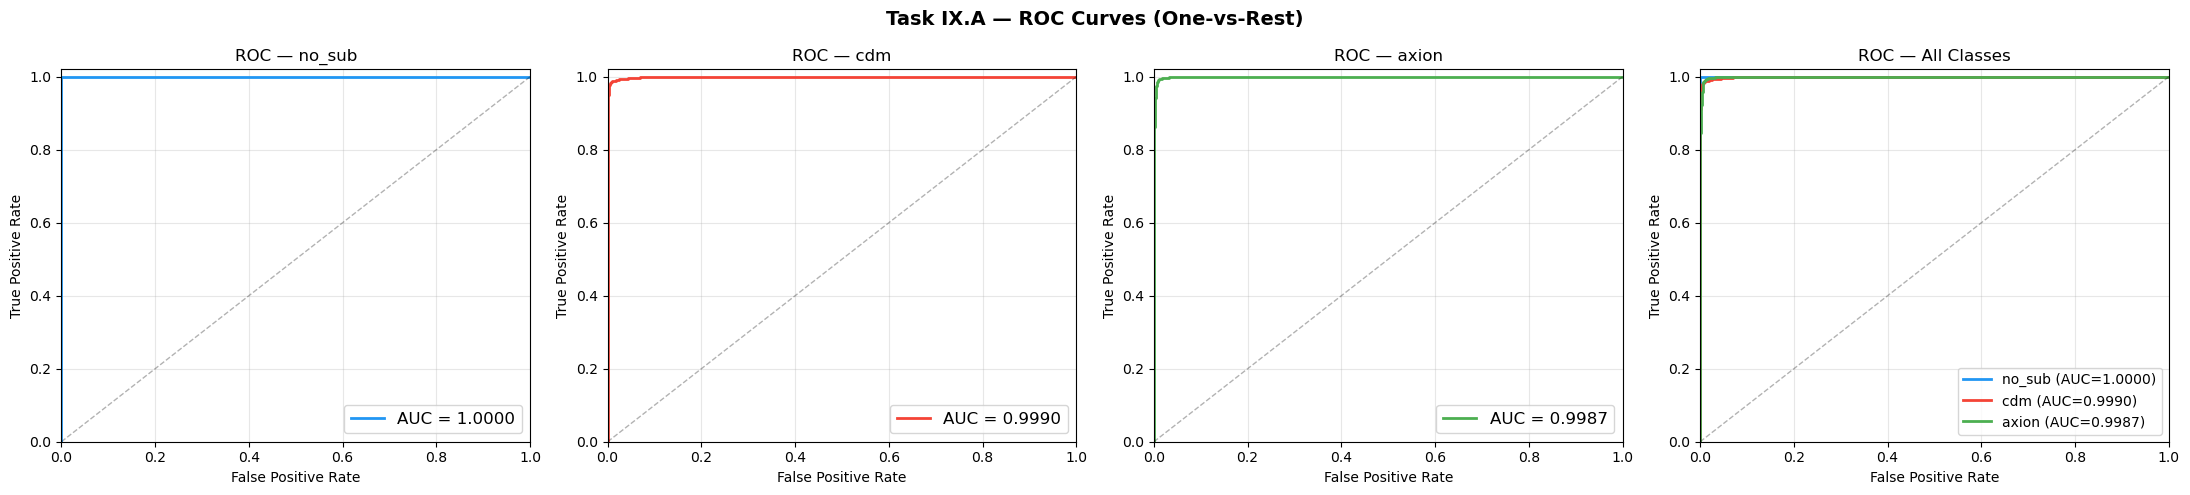


PER-CLASS AUC SCORES
    no_sub: 1.0000
       cdm: 0.9990
     axion: 0.9987
     Macro: 0.9992


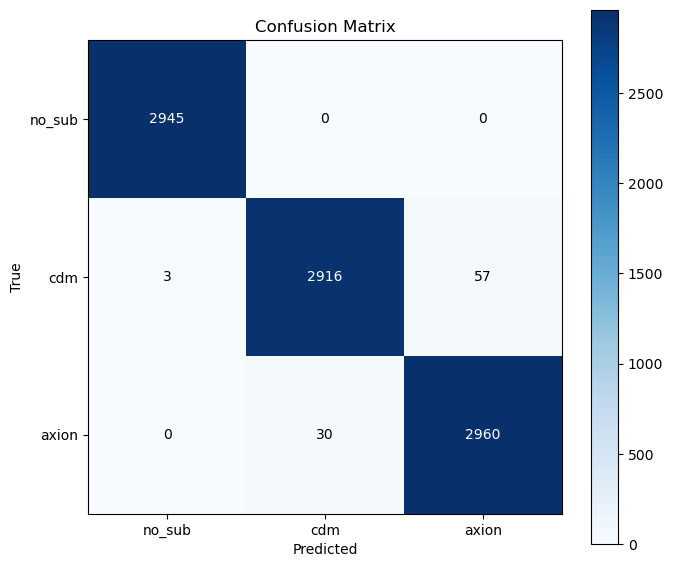

In [6]:
# Load best model
classifier.load_state_dict(torch.load("classifier_bestkg.pth", map_location=device))
classifier.eval()
 
all_probs = []
all_true = []
 
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        logits = classifier(imgs)
        probs = F.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_true.append(labels.numpy())
 
all_probs = np.concatenate(all_probs)
all_true = np.concatenate(all_true)
all_pred = all_probs.argmax(axis=1)
 
# ── Per-class ROC AUC (One-vs-Rest) ──
print("=" * 60)
print("EVALUATION RESULTS — Test Set")
print("=" * 60)
 
# Classification report
print(f"\nTest Accuracy: {(all_pred == all_true).mean():.4f}")
print(f"\nClassification Report:")
print(classification_report(all_true, all_pred, target_names=class_names, digits=4))
 
# Confusion matrix
cm = confusion_matrix(all_true, all_pred)
print(f"Confusion Matrix:")
print(cm)
 
# One-hot encode true labels for ROC
n_classes = cfg.num_classes
true_onehot = np.eye(n_classes)[all_true]
 
# Per-class ROC curves and AUC
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
colors = ['#2196F3', '#F44336', '#4CAF50']
auc_scores = {}
 
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(true_onehot[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores[cls] = roc_auc
 
    axes[i].plot(fpr, tpr, color=colors[i], lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[i].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.3)
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1.02])
    axes[i].set_xlabel('False Positive Rate')
    axes[i].set_ylabel('True Positive Rate')
    axes[i].set_title(f'ROC — {cls}')
    axes[i].legend(loc='lower right', fontsize=12)
    axes[i].grid(True, alpha=0.3)
 
# Combined ROC
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(true_onehot[:, i], all_probs[:, i])
    axes[3].plot(fpr, tpr, color=colors[i], lw=2, label=f'{cls} (AUC={auc_scores[cls]:.4f})')
axes[3].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.3)
axes[3].set_xlim([0, 1])
axes[3].set_ylim([0, 1.02])
axes[3].set_xlabel('False Positive Rate')
axes[3].set_ylabel('True Positive Rate')
axes[3].set_title('ROC — All Classes')
axes[3].legend(loc='lower right', fontsize=10)
axes[3].grid(True, alpha=0.3)
 
plt.suptitle("Task IX.A — ROC Curves (One-vs-Rest)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()
 
# Macro AUC
macro_auc = roc_auc_score(true_onehot, all_probs, average='macro', multi_class='ovr')
 
print(f"\n{'='*60}")
print(f"PER-CLASS AUC SCORES")
print(f"{'='*60}")
for cls, score in auc_scores.items():
    print(f"  {cls:>8s}: {score:.4f}")
print(f"  {'Macro':>8s}: {macro_auc:.4f}")
print(f"{'='*60}")
 
# ── Confusion matrix heatmap ──
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=range(n_classes), yticks=range(n_classes),
       xticklabels=class_names, yticklabels=class_names,
       xlabel='Predicted', ylabel='True',
       title='Confusion Matrix')
 
# Add text annotations
thresh = cm.max() / 2.
for i in range(n_classes):
    for j in range(n_classes):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
 
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
 

## Summary

In [9]:

test_acc = (all_pred == all_true).mean()

print(f"""
{'='*60}
 TASK IX.A — COMPLETE SUMMARY
{'='*60}

 Model
   Architecture:   MAE (ViT-Small encoder, 8×8 patches)
   Encoder:        dim={cfg.encoder_dim}, depth={cfg.encoder_depth}, heads={cfg.encoder_heads}
   Decoder:        dim={cfg.decoder_dim}, depth={cfg.decoder_depth}, heads={cfg.decoder_heads}
   Params:         {sum(p.numel() for p in classifier.parameters())/1e6:.1f}M (encoder+head)

 Pretraining
   Data:           {len(pretrain_files)} no_sub images
   Mask ratio:     {cfg.mask_ratio}
   Epochs:         {cfg.pretrain_epochs}

 Classification
   Split:          {len(train_idx)} train / {len(test_idx)} test (90/10)
   Epochs:         {cfg.finetune_epochs}
   Test Accuracy:  {test_acc:.4f}

 Per-Class AUC (One-vs-Rest)
   {'no_sub':>8s}:  {auc_scores['no_sub']:.4f}
   {'cdm':>8s}:  {auc_scores['cdm']:.4f}
   {'axion':>8s}:  {auc_scores['axion']:.4f}
   {'Macro':>8s}:  {macro_auc:.4f}

 Confusion Matrix
   {class_names[0]:>8s}: {cm[0]}
   {class_names[1]:>8s}: {cm[1]}
   {class_names[2]:>8s}: {cm[2]}

 Saved Weights
   mae_encoder_best.pth    — pretrained encoder
   mae_full_final.pth      — full MAE (for Task IX.B)
   classifier_bestkg.pth     — fine-tuned classifier
{'='*60}
""")


 TASK IX.A — COMPLETE SUMMARY

 Model
   Architecture:   MAE (ViT-Small encoder, 8×8 patches)
   Encoder:        dim=384, depth=12, heads=6
   Decoder:        dim=192, depth=4, heads=4
   Params:         21.3M (encoder+head)

 Pretraining
   Data:           29449 no_sub images
   Mask ratio:     0.75
   Epochs:         200

 Classification
   Split:          80193 train / 8911 test (90/10)
   Epochs:         50
   Test Accuracy:  0.9899

 Per-Class AUC (One-vs-Rest)
     no_sub:  1.0000
        cdm:  0.9990
      axion:  0.9987
      Macro:  0.9992

 Confusion Matrix
     no_sub: [2945    0    0]
        cdm: [   3 2916   57]
      axion: [   0   30 2960]

 Saved Weights
   mae_encoder_best.pth    — pretrained encoder
   mae_full_final.pth      — full MAE (for Task IX.B)
   classifier_bestkg.pth     — fine-tuned classifier

